# ROAD ACCIDENT DATA VISUALIZATION PORTAL

## Problem statement
- Road accidents cause deaths, injuries and financial losses.
- This project aims to analyze crash patterns and predict crash severity using historical data, help authorities and organizations take preventive measures.

## Objectives
- Identify the key factors that influence the severity of accidents
- Building a predictive model
- Create an interactive dashboard
- Generate actionable insights

## Importing Libraries

In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")


In [2]:
# pd.set_option("display.max_columns",None)
# pd.set_option("display.max_rows",None)

## Importing the Data

In [4]:
p_rta=pd.read_csv(r"C:\Users\Asus\Downloads\RTA.csv")
p_rta

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12311,16:15:00,Wednesday,31-50,Male,NaN,Employee,2-5yr,Lorry (11?40Q),Owner,NaN,...,Going straight,na,na,na,na,Driver,Normal,Not a Pedestrian,No distancing,Slight Injury
12312,18:00:00,Sunday,Unknown,Male,Elementary school,Employee,5-10yr,Automobile,Owner,NaN,...,Other,na,na,na,na,Driver,Normal,Not a Pedestrian,No distancing,Slight Injury
12313,13:55:00,Sunday,Over 51,Male,Junior high school,Employee,5-10yr,Bajaj,Owner,2-5yrs,...,Other,Driver or rider,Male,31-50,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Serious Injury
12314,13:55:00,Sunday,18-30,Female,Junior high school,Employee,Above 10yr,Lorry (41?100Q),Owner,2-5yrs,...,Other,na,na,na,na,Driver,Normal,Not a Pedestrian,Driving under the influence of drugs,Slight Injury


#### Describing the data

In [7]:
Describing the data_rta.describe()

,Number_of_vehicles_involved,Number_of_casualties
count,12316.000000,12316.000000
mean,2.040679,1.548149
std,0.688790,1.007179
min,1.000000,1.000000
25%,2.000000,1.000000
50%,2.000000,1.000000
75%,2.000000,2.000000
max,7.000000,8.000000


In [8]:
p_rta.isna().sum().sort_values(ascending=False)

Defect_of_vehicle              4427
Service_year_of_vehicle        3928
Work_of_casuality              3198
Fitness_of_casuality           2635
Type_of_vehicle                 950
Types_of_Junction               887
Driving_experience              829
Educational_level               741
Vehicle_driver_relation         579
Owner_of_vehicle                482
Lanes_or_Medians                385
Vehicle_movement                308
Area_accident_occured           239
Road_surface_type               172
Type_of_collision               155
Road_allignment                 142
Casualty_class                    0
Pedestrian_movement               0
Cause_of_accident                 0
Casualty_severity                 0
Age_band_of_casualty              0
Sex_of_casualty                   0
Time                              0
Road_surface_conditions           0
Number_of_casualties              0
Number_of_vehicles_involved       0
Weather_conditions                0
Light_conditions            

In [10]:
df=p_rta.isna().sum().sort_values(ascending=False)/len(p_rta)*100
df

Defect_of_vehicle              35.945112
Service_year_of_vehicle        31.893472
Work_of_casuality              25.966223
Fitness_of_casuality           21.394933
Type_of_vehicle                 7.713543
Types_of_Junction               7.202014
Driving_experience              6.731082
Educational_level               6.016564
Vehicle_driver_relation         4.701202
Owner_of_vehicle                3.913608
Lanes_or_Medians                3.126015
Vehicle_movement                2.500812
Area_accident_occured           1.940565
Road_surface_type               1.396557
Type_of_collision               1.258525
Road_allignment                 1.152972
Casualty_class                  0.000000
Pedestrian_movement             0.000000
Cause_of_accident               0.000000
Casualty_severity               0.000000
Age_band_of_casualty            0.000000
Sex_of_casualty                 0.000000
Time                            0.000000
Road_surface_conditions         0.000000
Number_of_casual

## Data Cleaning

#### 1. Droping the Data

In [11]:
p_rta.drop(["Time","Service_year_of_vehicle","Work_of_casuality","Fitness_of_casuality",
              "Day_of_week","Educational_level","Defect_of_vehicle","Sex_of_driver",
              "Casualty_class","Sex_of_casualty","Age_band_of_casualty","Casualty_severity","Pedestrian_movement"],
             axis=1,inplace=True)


In [12]:
# Insights

#### 2. Handling Missing Data

In [15]:
df=p_rta.isna().sum().sort_values(ascending=False)/len(p_rta)*100
df

Type_of_vehicle                7.713543
Types_of_Junction              7.202014
Driving_experience             6.731082
Vehicle_driver_relation        4.701202
Owner_of_vehicle               3.913608
Lanes_or_Medians               3.126015
Vehicle_movement               2.500812
Area_accident_occured          1.940565
Road_surface_type              1.396557
Type_of_collision              1.258525
Road_allignment                1.152972
Number_of_vehicles_involved    0.000000
Cause_of_accident              0.000000
Number_of_casualties           0.000000
Age_band_of_driver             0.000000
Weather_conditions             0.000000
Light_conditions               0.000000
Road_surface_conditions        0.000000
Accident_severity              0.000000
dtype: float64

#### Fill missing values in each column

In [21]:
# Forward Fill (ffill)
p_rta["Type_of_vehicle"] = p_rta["Type_of_vehicle"].ffill()
p_rta["Area_accident_occured"] = p_rta["Area_accident_occured"].ffill()

In [22]:
# Fill with "Unknown"
p_rta["Types_of_Junction"] = p_rta["Types_of_Junction"].fillna("Unknown")
p_rta["Driving_experience"] = p_rta["Driving_experience"].fillna("Unknown")
p_rta["Lanes_or_Medians"] = p_rta["Lanes_or_Medians"].fillna("Unknown")

In [23]:
# Fill with "No Value"
p_rta["Vehicle_movement"] = p_rta["Vehicle_movement"].fillna("No Value")
p_rta["Type_of_collision"] = p_rta["Type_of_collision"].fillna("No Value")
p_rta["Road_allignment"] = p_rta["Road_allignment"].fillna("No Value")

In [24]:
# Backward Fill (bfill)
p_rta["Vehicle_driver_relation"] = p_rta["Vehicle_driver_relation"].bfill()
p_rta["Road_surface_type"] = p_rta["Road_surface_type"].bfill()

In [27]:
# Fill mode (most frequent value) for categorical column
p_rta["Owner_of_vehicle"] = p_rta["Owner_of_vehicle"].fillna(
    p_rta["Owner_of_vehicle"].mode()[0]
)

In [28]:
df=p_rta.isna().sum().sort_values(ascending=False)/len(p_rta)*100
df

Age_band_of_driver             0.0
Road_surface_conditions        0.0
Cause_of_accident              0.0
Vehicle_movement               0.0
Number_of_casualties           0.0
Number_of_vehicles_involved    0.0
Type_of_collision              0.0
Weather_conditions             0.0
Light_conditions               0.0
Road_surface_type              0.0
Vehicle_driver_relation        0.0
Types_of_Junction              0.0
Road_allignment                0.0
Lanes_or_Medians               0.0
Area_accident_occured          0.0
Owner_of_vehicle               0.0
Type_of_vehicle                0.0
Driving_experience             0.0
Accident_severity              0.0
dtype: float64

In [29]:
# Insights

#### 3. Handling Duplicates

In [30]:
p_rta.duplicated().sum()

np.int64(11)

In [31]:
p_rta.drop_duplicates(inplace=True,keep="first") # Droping Duplicates Rows

In [32]:
p_rta.duplicated().sum()

np.int64(0)

In [33]:
p_rta.shape

(12305, 19)

## Data Visualization & EDA

#### 1. Univariate Analysis

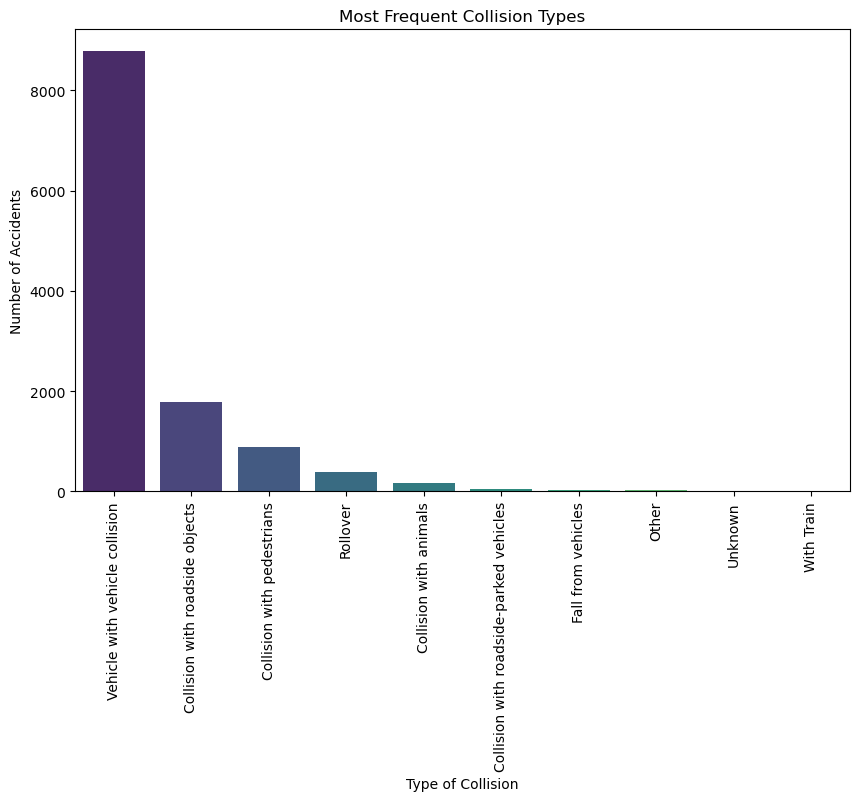

In [5]:
## Which type of collision occurs most frequently? (Bar Chart)

collision_counts = p_rta['Type_of_collision'].value_counts()
plt.figure(figsize=(10,6))
sns.barplot(x=collision_counts.index, y=collision_counts.values, palette="viridis")
plt.title("Most Frequent Collision Types")
plt.xlabel("Type of Collision")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=90)
plt.show()

**Insight**: The chart shows that vehicle-to-vehicle collisions dominate accident frequency, making them the primary focus area for road safety interventions. In contrast, collisions with pedestrians and roadside objects are the next most common, highlighting critical risks for vulnerable road users and infrastructure.

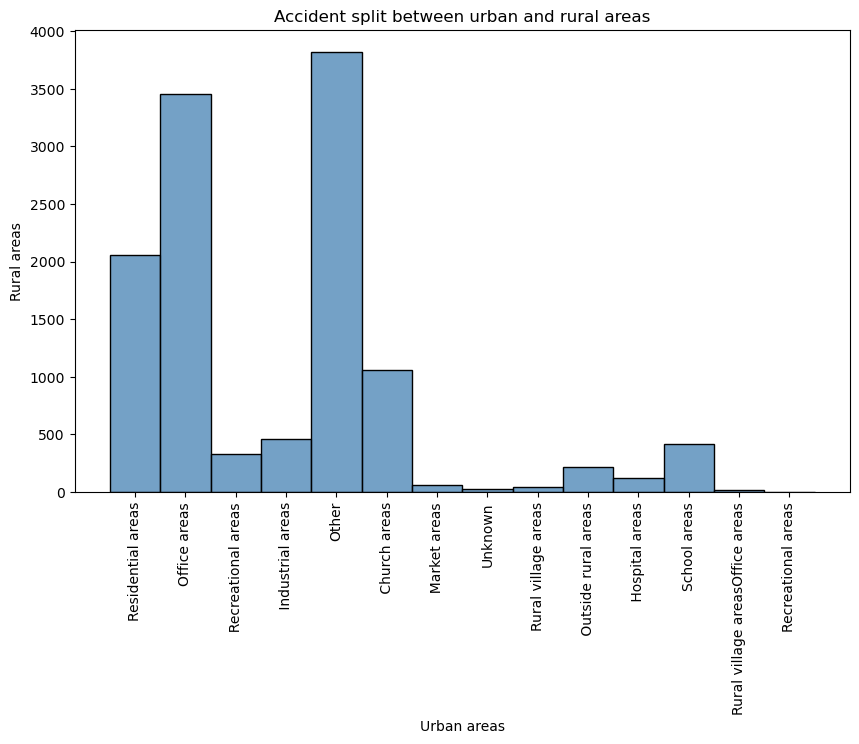

In [6]:
## How are accidents split between urban vs rural areas? (histogram)

plt.figure(figsize=(10,6))
sns.histplot(p_rta["Area_accident_occured"],bins=10,kde=False,color="steelblue")
plt.title("Accident split between urban and rural areas")
plt.xlabel("Urban areas")
plt.ylabel("Rural areas")
plt.xticks(rotation=90)
plt.show()

**Insight**: Accidents are most concentrated in office, residential, and “other” urban areas, showing that dense activity zones face higher risks. In contrast, rural and specialized locations like markets or churches record far fewer incidents, indicating lower exposure but still notable vulnerability.

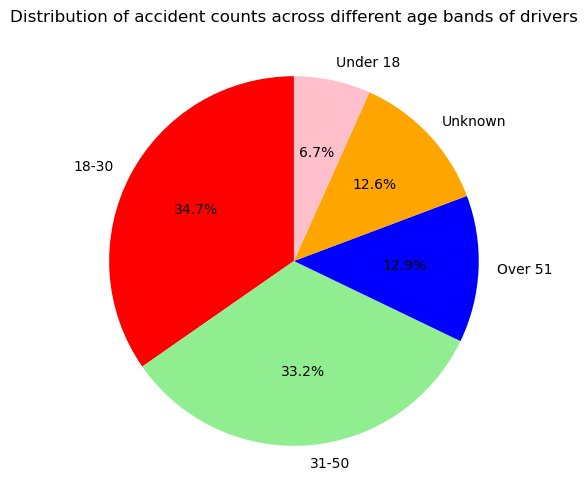

In [4]:
## What is the distribution of accident counts across different age bands of drivers? (pie chart) ✅

area_counts = p_rta['Age_band_of_driver'].value_counts()
plt.figure(figsize=(10,6))
plt.pie(area_counts, labels = area_counts.index, autopct='%1.1f%%', 
        startangle=90, colors=['Red','lightgreen','blue','orange','pink'])
plt.title("Distribution of accident counts across different age bands of drivers")
plt.show()

**Insight**: Drivers aged 18–30 account for the largest share of accidents, closely followed by those in the 31–50 age group, highlighting higher risk among active-age drivers. Meanwhile, under-18 and over-51 drivers contribute far fewer cases, though still notable compared to the “unknown” category.